In [13]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]



In [14]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEndpointEmbeddings

In [15]:
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["HUGGINGFACEHUB_API_TOKEN"] = os.getenv("HUGGINGFACEHUB_API_TOKEN")
os.environ["TAVILY_API_KEY"]= os.getenv("TAVILY_API_KEY")

In [16]:
docs=[WebBaseLoader(url).load() for url in urls]
docs_list=[l for sublist in docs for l in sublist]
chunks=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50).split_documents(docs_list)

embeddings=HuggingFaceEndpointEmbeddings(
    repo_id="sentence-transformers/all-MiniLM-L6-v2",task="feature-extraction")
store=FAISS.from_documents(chunks,embeddings)
retriever=store.as_retriever()
retriever

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEndpointEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x7fe50e344470>, search_kwargs={})

In [18]:
from pydantic import Field,BaseModel
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
class GradeState(BaseModel):
    binary_score:str =Field(description="Documents relevent to the question " \
    ", 'yes' or 'no'")


llm=ChatGroq(model="llama-3.3-70b-versatile")
structured_llm=llm.with_structured_output(GradeState)

system_prompt="""You are an expert grader assessing the relevance of a retrieved document to a user question.

Your task:
1. Carefully read the retrieved document and the user question.
2. Determine if the document contains enough information or context to help answer the question.
3. If the document is relevant, your output must be 'yes'.
4. If the document is not relevant, your output must be 'no'.

Constraint:
Your response must be a single word, either 'yes' or 'no'. Do not include any explanation, preamble, or additional text."""

grade_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",system_prompt),
        ("human","the relevant Documents {documents} /n/n the question is {question}  ")

    ]
)
grading=grade_prompt | structured_llm

question = "agent memory"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(grading.invoke({"question": question, "documents": doc_txt}))


binary_score='yes'


In [25]:
from langsmith import Client
from langchain_core.output_parsers import StrOutputParser
client = Client()
prompt = client.pull_prompt("rlm/rag-prompt")

chain=prompt | llm |StrOutputParser()

chain.invoke({"context": docs, "question": question})

'An agent\'s memory consists of two types: short-term memory, which utilizes in-context learning to learn, and long-term memory, which provides the capability to retain and recall information over extended periods using an external vector store and fast retrieval. The long-term memory module is often referred to as a "memory stream" or external database that records the agent\'s experience in natural language. This memory enables the agent to behave conditioned on past experience and interact with other agents.'

In [26]:
from langsmith import Client

client = Client()
re_write_prompt = client.pull_prompt("efriis/self-rag-question-rewriter")
rewriting=re_write_prompt | llm | StrOutputParser()
rewriting.invoke({"question":"agent memory"})

'Based on the input question "agent memory", I\'ll attempt to reason about the underlying semantic intent. It appears to be related to artificial intelligence or computer science, possibly referring to the memory or knowledge storage of an intelligent agent.\n\nHere\'s an improved question:\n\n"What are the concepts and mechanisms related to memory management in artificial intelligence agents?"\n\nAlternatively, depending on the context, it could also be:\n\n* "How do intelligent agents store and retrieve information?"\n* "What is the role of memory in agent-based systems?"\n* "What are the techniques used to implement memory in artificial intelligence agents?"\n\nThese rephrased questions aim to provide more clarity and specificity, making it easier to retrieve relevant information from a vector store.'

In [27]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily_search=TavilySearchResults(k=2)

/tmp/ipykernel_201530/3639083677.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search=TavilySearchResults(k=2)


In [28]:
from typing import TypedDict
class State(TypedDict):
    documents:list[str]
    question:str
    web_search:str
    generation:str

In [40]:
from langchain_core.documents import Document

def retrieve_data(state:State) -> State:
    question=state["question"]
    results=retriever.invoke(question)
    return {"question":question,"documents":results}

def grade(state:State) -> State:
    question=state["question"]
    results=state["documents"]
    web_search="no"
    filtered_docs=[]
    for doc in results:
        score=grading.invoke({"question": question, "documents": doc.page_content})

        grade=score.binary_score
        if grade=="yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(doc)
        else:
            print("grading")
            web_search="yes"
            continue

    return {"documents":filtered_docs,"question":question,"web_search":web_search}

def generate_answer(state:State) -> State:
    question=state["question"]
    results=state["documents"]
    generation=chain.invoke({"context": results, "question": question})
    return {"question":question,"documents":results,"generation":generation}

def web_serach(state: State):
    question = state["question"]
    documents = state["documents"]
    
    # تنفيذ البحث
    docs = tavily_search.invoke({"query": question})
    
    # التأكد من طريقة استخراج المحتوى
    # لو Tavily بترجع محتوى نصي مباشر (String)
    if isinstance(docs, str):
        web_results = docs
    else:
        # لو بترجع قائمة، بنجمع المحتوى منها بأمان
        web_results = "\n".join([d.get("content", str(d)) if isinstance(d, dict) else str(d) for d in docs])
    
    # تحويل النتيجة لـ Document وإضافتها للقائمة
    new_doc = Document(page_content=web_results, metadata={"source": "tavily_search"})
    documents.append(new_doc)
    
    return {"documents": documents}

def rewrite(state:State) -> State:
    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = rewriting.invoke({"question": question})
    return {"documents": documents, "question": better_question}

def route(state:State) -> State:
    score=state["web_search"]

    if score == "yes":
        return "rewriter"
    else:
        return "generator"


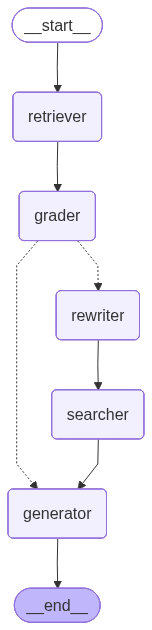

In [41]:
from langgraph.graph import StateGraph,START,END

graph=StateGraph(State)

graph.add_node("retriever",retrieve_data)
graph.add_node("rewriter",rewrite)
graph.add_node("grader",grade)
graph.add_node("generator",generate_answer)
graph.add_node("searcher",web_serach)


graph.set_entry_point("retriever")
graph.add_edge("retriever","grader")
graph.add_conditional_edges("grader",route,{
    "rewriter":"rewriter"
    ,"generator":"generator"
})
graph.add_edge("rewriter","searcher")
graph.add_edge("searcher","generator")
graph.add_edge("generator",END)

builder=graph.compile()
builder

In [42]:
builder.invoke({"question":"What are the types of agent memory?"})

---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
grading
---GRADE: DOCUMENT RELEVANT---
---TRANSFORM QUERY---


{'documents': [Document(id='c3117cea-007c-4a49-8339-6dd1fe84ca7c', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for 